# Notebook 3: Decision Tree với Sklearn
## Chạy sklearn DecisionTreeClassifier để so sánh với From Scratch

**Mục tiêu:** Tạo baseline bằng sklearn, cùng dataset + cùng tham số với From Scratch.


In [2]:
# ====== SETUP CHO GOOGLE COLAB ======
# Chạy cell này ĐẦU TIÊN khi dùng Colab
import os

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Đường dẫn tới project trên Drive
PROJECT_DIR = '/content/drive/MyDrive/kpdl'
os.chdir(PROJECT_DIR)

# Thêm src/ vào Python path
import sys
sys.path.insert(0, PROJECT_DIR)

print(f'Working directory: {os.getcwd()}')
print(f'Files: {os.listdir(".")}')
print('✅ Setup complete!')

Mounted at /content/drive
Working directory: /content/drive/MyDrive/kpdl
Files: ['report', 'data', 'src', 'notebooks']
✅ Setup complete!


In [4]:
import numpy as np
import pandas as pd
import pickle
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.model_selection import cross_val_score, StratifiedKFold

print("Libraries loaded.")


Libraries loaded.


In [5]:
# Load processed data
with open("data/processed_data.pkl", "rb") as f:
    data = pickle.load(f)
X_train, X_test = data["X_train"], data["X_test"]
y_train, y_test = data["y_train"], data["y_test"]
feature_names = data["feature_names"]
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (32940, 63), Test: (8236, 63)


## 1. GINI — max_depth=5


In [ ]:
# GINI depth=5
t0 = time.time()
sk_gini = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)
sk_gini.fit(X_train, y_train)
t_train = time.time() - t0

t0 = time.time()
y_pred_gini = sk_gini.predict(X_test)
t_pred = time.time() - t0

print(f"Training time: {t_train:.4f}s")
print(f"Prediction time: {t_pred:.4f}s")
print(f"Depth: {sk_gini.get_depth()}, Leaves: {sk_gini.get_n_leaves()}")
print(f"{classification_report(y_test, y_pred_gini)}")


Training time: 0.2773s
Prediction time: 0.0235s
Depth: 5, Leaves: 31
              precision    recall  f1-score   support

          no       0.94      0.97      0.95      7308
         yes       0.65      0.51      0.57       928

    accuracy                           0.91      8236
   macro avg       0.80      0.74      0.76      8236
weighted avg       0.91      0.91      0.91      8236



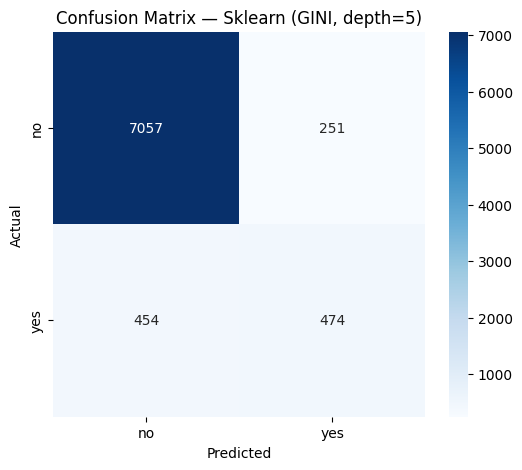

In [ ]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_gini, labels=["no", "yes"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["no","yes"], yticklabels=["no","yes"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Sklearn (GINI, depth=5)")
plt.savefig("report/fig_sklearn_cm_gini.png", dpi=150, bbox_inches="tight")
plt.show()


## 2. Entropy — max_depth=5


In [ ]:
# Entropy depth=5
sk_entropy = DecisionTreeClassifier(criterion="entropy", max_depth=5, random_state=42)
sk_entropy.fit(X_train, y_train)
y_pred_ent = sk_entropy.predict(X_test)
print(f"Depth: {sk_entropy.get_depth()}, Leaves: {sk_entropy.get_n_leaves()}")
print(f"{classification_report(y_test, y_pred_ent)}")


Depth: 5, Leaves: 31
              precision    recall  f1-score   support

          no       0.94      0.96      0.95      7308
         yes       0.65      0.51      0.57       928

    accuracy                           0.91      8236
   macro avg       0.79      0.74      0.76      8236
weighted avg       0.91      0.91      0.91      8236



## 3. Visualize Tree


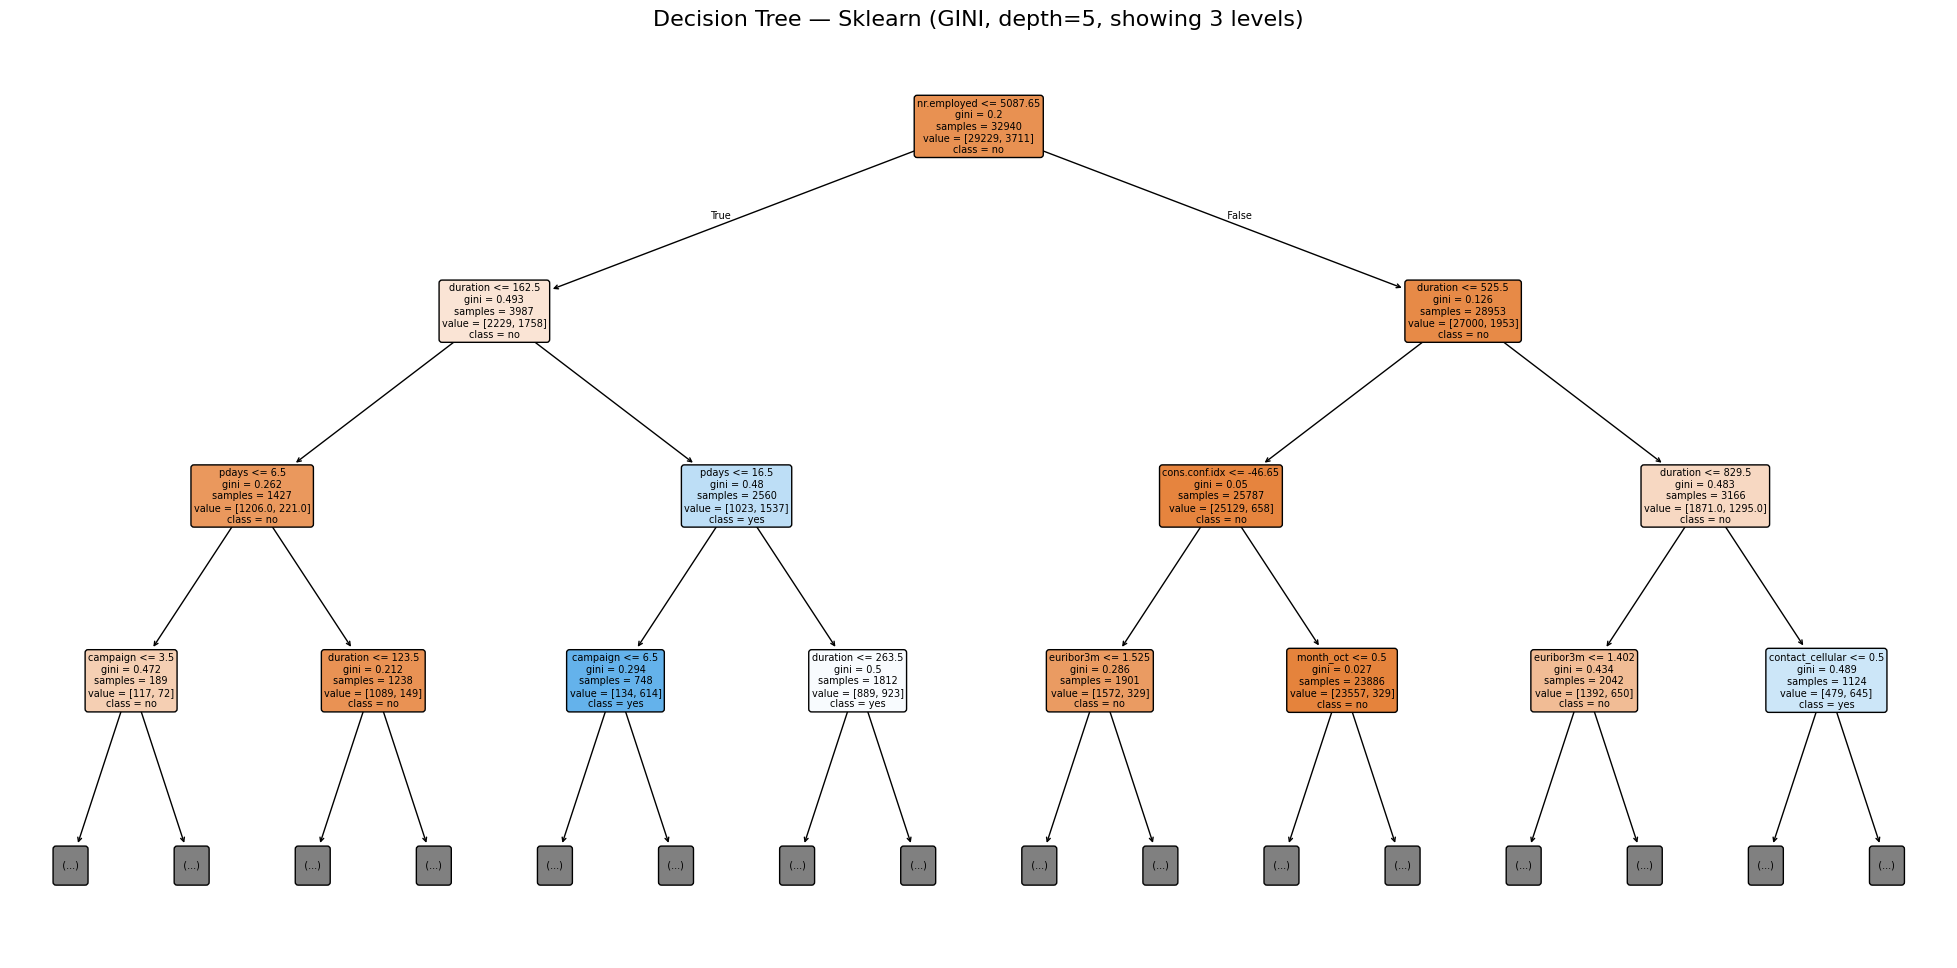

In [ ]:
# Vẽ cây sklearn
fig, ax = plt.subplots(figsize=(25, 12))
plot_tree(sk_gini, feature_names=feature_names, class_names=["no", "yes"],
          filled=True, rounded=True, fontsize=7, ax=ax, max_depth=3)
ax.set_title("Decision Tree — Sklearn (GINI, depth=5, showing 3 levels)", fontsize=16)
plt.savefig("report/fig_sklearn_tree.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# Text representation
tree_text = export_text(sk_gini, feature_names=feature_names, max_depth=3)
print("Cây quyết định (text, 3 levels):")
print(tree_text)


Cây quyết định (text, 3 levels):
|--- nr.employed <= 5087.65
|   |--- duration <= 162.50
|   |   |--- pdays <= 6.50
|   |   |   |--- campaign <= 3.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- campaign >  3.50
|   |   |   |   |--- class: no
|   |   |--- pdays >  6.50
|   |   |   |--- duration <= 123.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- duration >  123.50
|   |   |   |   |--- truncated branch of depth 2
|   |--- duration >  162.50
|   |   |--- pdays <= 16.50
|   |   |   |--- campaign <= 6.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- campaign >  6.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- pdays >  16.50
|   |   |   |--- duration <= 263.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- duration >  263.50
|   |   |   |   |--- truncated branch of depth 2
|--- nr.employed >  5087.65
|   |--- duration <= 525.50
|   |   |--- cons.conf.idx <= -46.65
|   |   |   |--- euribor3m

## 4. Feature Importance


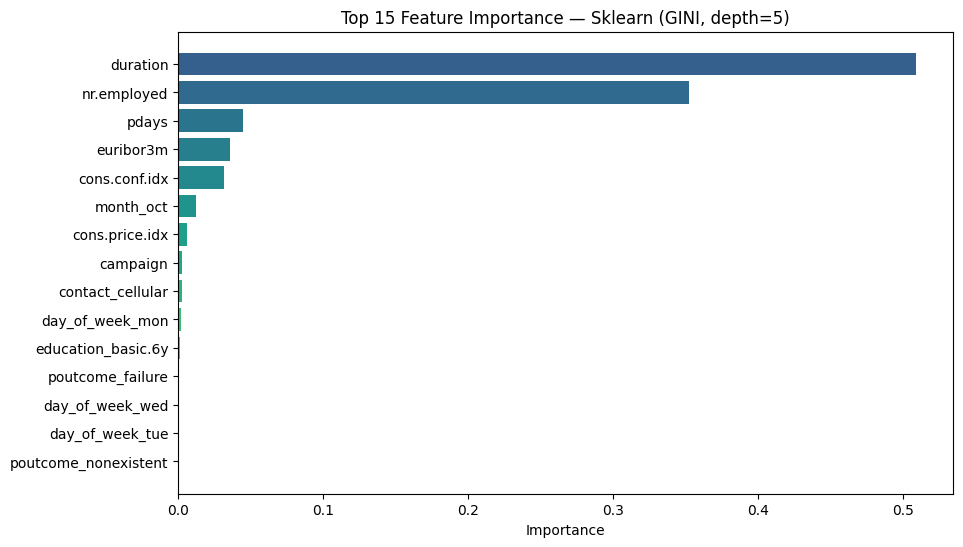

Top 10:
   1. duration                       0.5094
   2. nr.employed                    0.3525
   3. pdays                          0.0445
   4. euribor3m                      0.0357
   5. cons.conf.idx                  0.0318
   6. month_oct                      0.0122
   7. cons.price.idx                 0.0061
   8. campaign                       0.0027
   9. contact_cellular               0.0024
  10. day_of_week_mon                0.0016


In [ ]:
# Feature importance
importances = sk_gini.feature_importances_
indices = np.argsort(importances)[::-1][:15]

fig, ax = plt.subplots(figsize=(10, 6))
names = [feature_names[i] for i in indices]
values = importances[indices]
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(names)))
ax.barh(range(len(names)), values, color=colors)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.invert_yaxis()
ax.set_xlabel("Importance")
ax.set_title("Top 15 Feature Importance — Sklearn (GINI, depth=5)")
plt.savefig("report/fig_sklearn_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10:")
for rank, i in enumerate(indices[:10], 1):
    print(f"  {rank:2d}. {feature_names[i]:30s} {importances[i]:.4f}")


## 5. Depth Analysis


max_depth=    2: train=0.9029, test=0.9046, depth=2, leaves=4
max_depth=    3: train=0.9080, test=0.9094, depth=3, leaves=8
max_depth=    4: train=0.9141, test=0.9116, depth=4, leaves=16
max_depth=    5: train=0.9173, test=0.9144, depth=5, leaves=31
max_depth=    7: train=0.9236, test=0.9162, depth=7, leaves=111
max_depth=   10: train=0.9377, test=0.9100, depth=10, leaves=419
max_depth=   15: train=0.9733, test=0.8972, depth=15, leaves=1409
max_depth=   20: train=0.9956, test=0.8899, depth=20, leaves=2198
max_depth= None: train=1.0000, test=0.8898, depth=28, leaves=2353


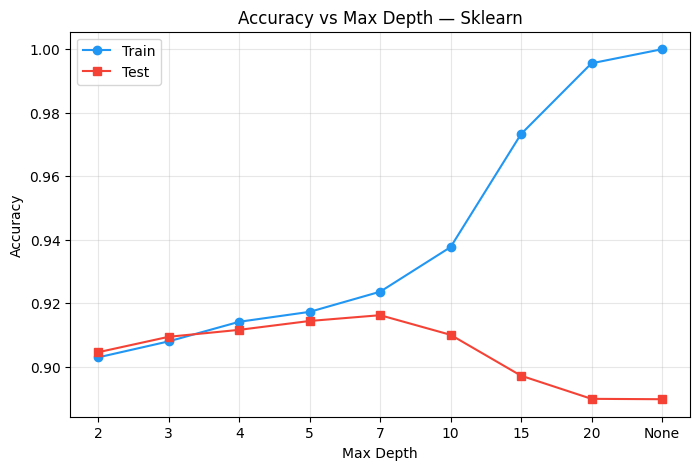

In [ ]:
# Accuracy vs max_depth
depths = [2, 3, 4, 5, 7, 10, 15, 20, None]
sk_results = []

for d in depths:
    dt = DecisionTreeClassifier(criterion="gini", max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, dt.predict(X_train))
    te_acc = accuracy_score(y_test, dt.predict(X_test))
    dl = str(d) if d else "None"
    sk_results.append({"max_depth": dl, "train_acc": tr_acc, "test_acc": te_acc,
                       "depth": dt.get_depth(), "leaves": dt.get_n_leaves()})
    print(f"max_depth={dl:>5s}: train={tr_acc:.4f}, test={te_acc:.4f}, depth={dt.get_depth()}, leaves={dt.get_n_leaves()}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(len(depths)), [r["train_acc"] for r in sk_results], "o-", label="Train", color="#2196F3")
ax.plot(range(len(depths)), [r["test_acc"] for r in sk_results], "s-", label="Test", color="#F44336")
ax.set_xticks(range(len(depths)))
ax.set_xticklabels([str(d) if d else "None" for d in depths])
ax.set_xlabel("Max Depth"); ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs Max Depth — Sklearn")
ax.legend(); ax.grid(True, alpha=0.3)
plt.savefig("report/fig_sklearn_depth_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Cross-Validation (5-fold)


In [6]:
# 5-fold stratified CV
from sklearn.metrics import make_scorer

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_dt = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)

scores = cross_val_score(best_dt, X_train, y_train, cv=cv, scoring="accuracy")

# F1 cho class 'yes' — đồng bộ với from scratch (Notebook 2)
f1_yes_scorer = make_scorer(f1_score, pos_label='yes')
f1_scores = cross_val_score(best_dt, X_train, y_train, cv=cv, scoring=f1_yes_scorer)

print("=== 5-Fold Stratified Cross-Validation ===")
print(f"Accuracy:  {scores.mean():.4f} ± {scores.std():.4f}")
print(f"F1 (yes):  {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
print(f"Per-fold Accuracy: {[f'{s:.4f}' for s in scores]}")
print(f"Per-fold F1 (yes): {[f'{s:.4f}' for s in f1_scores]}")
print()
print("→ Metric F1 báo cho class 'yes' để đồng bộ so sánh với From Scratch.")


=== 5-Fold Stratified Cross-Validation ===
Accuracy:  0.9150 ± 0.0011
F1 (yes):  0.5747 ± 0.0104
Per-fold Accuracy: ['0.9141', '0.9170', '0.9153', '0.9145', '0.9141']
Per-fold F1 (yes): ['0.5832', '0.5909', '0.5668', '0.5666', '0.5660']

→ Metric F1 báo cho class 'yes' để đồng bộ so sánh với From Scratch.


In [ ]:
# Save results
results_sklearn = {
    "gini_depth5": {
        "accuracy": accuracy_score(y_test, y_pred_gini),
        "precision": precision_score(y_test, y_pred_gini, pos_label="yes"),
        "recall": recall_score(y_test, y_pred_gini, pos_label="yes"),
        "f1": f1_score(y_test, y_pred_gini, pos_label="yes"),
        "depth": sk_gini.get_depth(), "leaves": sk_gini.get_n_leaves()
    },
    "entropy_depth5": {
        "accuracy": accuracy_score(y_test, y_pred_ent),
        "precision": precision_score(y_test, y_pred_ent, pos_label="yes"),
        "recall": recall_score(y_test, y_pred_ent, pos_label="yes"),
        "f1": f1_score(y_test, y_pred_ent, pos_label="yes"),
        "depth": sk_entropy.get_depth(), "leaves": sk_entropy.get_n_leaves()
    },
    "feature_importances": dict(zip(feature_names, sk_gini.feature_importances_)),
    "depth_analysis": sk_results,
    "cv_accuracy": {"mean": scores.mean(), "std": scores.std(), "folds": scores.tolist()},
    "cv_f1": {"mean": f1_scores.mean(), "std": f1_scores.std(), "folds": f1_scores.tolist()}
}
with open("data/results_sklearn.pkl", "wb") as f:
    pickle.dump(results_sklearn, f)
print("✅ Kết quả sklearn đã lưu tại: data/results_sklearn.pkl")


✅ Kết quả sklearn đã lưu tại: data/results_sklearn.pkl
